# 03 — Per-capita crime rates by borough

In `02_boroughs.ipynb` we found Westminster's raw crime count was far above
every other borough, and flagged that this might just reflect footfall
(tourists, workers, shoppers) rather than danger to residents. This
notebook brings in ONS population estimates to test that, by computing a
genuine **crimes-per-1,000-residents** rate instead of a raw total.

In [1]:
import sys
sys.path.append("../../src")

import matplotlib.pyplot as plt
import seaborn as sns

from load_data import load_force_data, load_borough_population
from clean import clean_crime_data, add_borough_column, LONDON_BOROUGHS

sns.set_theme(style="whitegrid")

london = load_force_data("london")
london = clean_crime_data(london)
london = add_borough_column(london)
ldn = london[london["Borough"].isin(LONDON_BOROUGHS)]

pop = load_borough_population()
pop.head()

,Borough,Population
202,Camden,216943
203,City of London,15111
204,Hackney,266758
205,Hammersmith and Fulham,188687
206,Haringey,263850


**Source:** ONS "Population estimates for England and Wales: mid-2024",
sheet MYE2 (population by single year of age), filtered to rows tagged
`Geography == "London Borough"` — see `load_borough_population()` in
`src/load_data.py` for exactly how it's parsed out of the raw spreadsheet.

In [2]:
# Before merging, check the two Borough columns actually mean the same set
# of 33 names -- if even one name differed slightly (e.g. trailing space,
# "&" vs "and"), the merge below would silently produce a missing value
# instead of an error.
set(pop["Borough"]) == LONDON_BOROUGHS

True

In [3]:
# groupby + size -> one row count per borough. .rename("Crimes") names the
# resulting Series so it becomes a sensible column name after reset_index().
counts = ldn.groupby("Borough").size().rename("Crimes").reset_index()

# merge joins two DataFrames on a shared column ("Borough" here), like a
# SQL JOIN. validate="one_to_one" makes pandas RAISE an error if either
# side has duplicate Borough values -- a good habit any time a merge
# should produce exactly one matched row per input row. Silent duplication
# is one of the most common sources of subtly wrong analysis.
merged = counts.merge(pop, on="Borough", how="left", validate="one_to_one")

merged["rate_per_1000"] = merged["Crimes"] / merged["Population"] * 1000
merged.sort_values("rate_per_1000", ascending=False).head()

,Borough,Crimes,Population,rate_per_1000
32,Westminster,97632,209996,464.923141
5,Camden,51502,216943,237.398764
18,Islington,44201,223024,198.189433
19,Kensington and Chelsea,28459,144518,196.923567
27,Southwark,52843,314786,167.869600


## Chart — crime rate per capita by borough

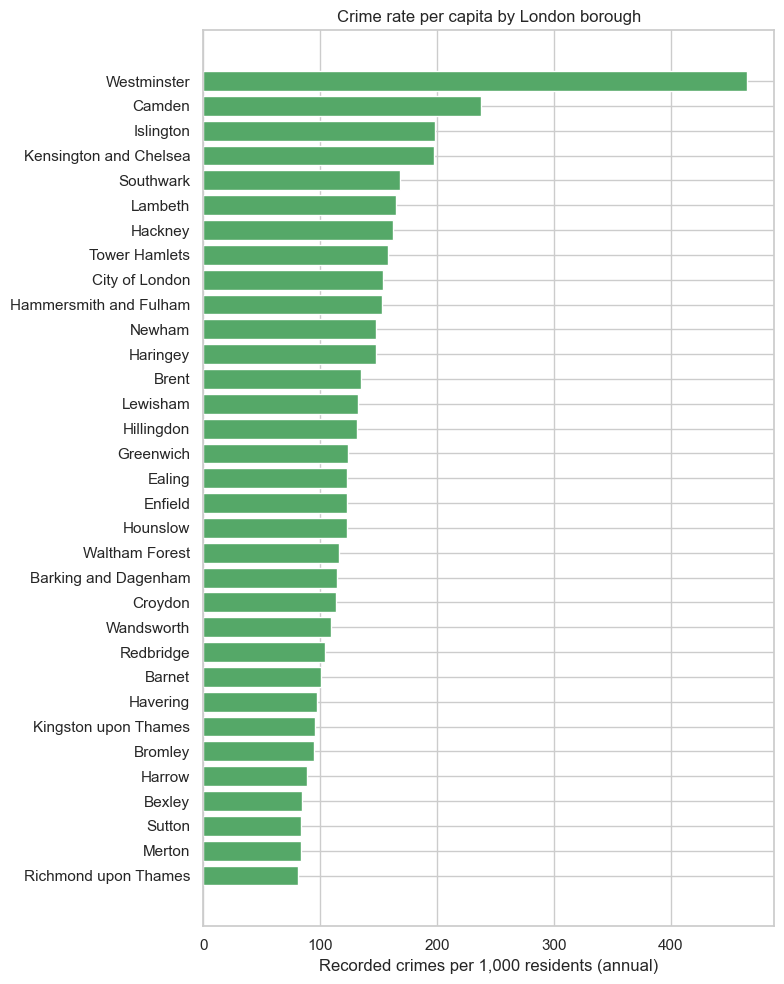

In [4]:
rate_sorted = merged.sort_values("rate_per_1000")

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(rate_sorted["Borough"], rate_sorted["rate_per_1000"], color="#55A868")
ax.set_xlabel("Recorded crimes per 1,000 residents (annual)")
ax.set_title("Crime rate per capita by London borough")
fig.tight_layout()

### Findings

- **Westminster stays #1, but the story changes.** Its rate is
  **~465 crimes per 1,000 residents per year** — nearly half the resident
  population's worth of crime, annually. That's not plausible as "crime
  happening to residents"; it confirms the footfall theory from notebook
  02. A more honest phrasing: Westminster records an extreme *volume* of
  crime relative to its small resident base, driven by the huge non-resident
  population passing through it.
- **Camden jumps from mid-table (raw counts) to #2 per-capita** — a
  genuinely different insight than the raw bar chart in notebook 02 showed.
- **City of London jumps from last place (raw counts) to #8 per-capita** —
  for the mirror-image reason to Westminster. Its resident population is
  tiny (~15,000) because it's the financial district, so even a modest
  crime count divided by that small denominator produces a misleadingly
  high rate. Same lesson as Westminster, opposite direction: **per-capita
  rates are only meaningful when "resident population" is actually a good
  proxy for "people exposed to crime risk there" — and for both these
  boroughs, it isn't.**
- For the remaining 31 boroughs, where residents make up most of the people
  actually in the borough day-to-day, the per-capita rate is a much fairer
  comparison than the raw count was.

## Chart — population vs. total crime

A scatter plot makes the same point visually: most boroughs roughly track
a population-crime relationship, and Westminster is a clear vertical
outlier — far more crime than its population alone would predict. Per the
"selective labels" rule (never label every point), only the outliers worth
naming are annotated.

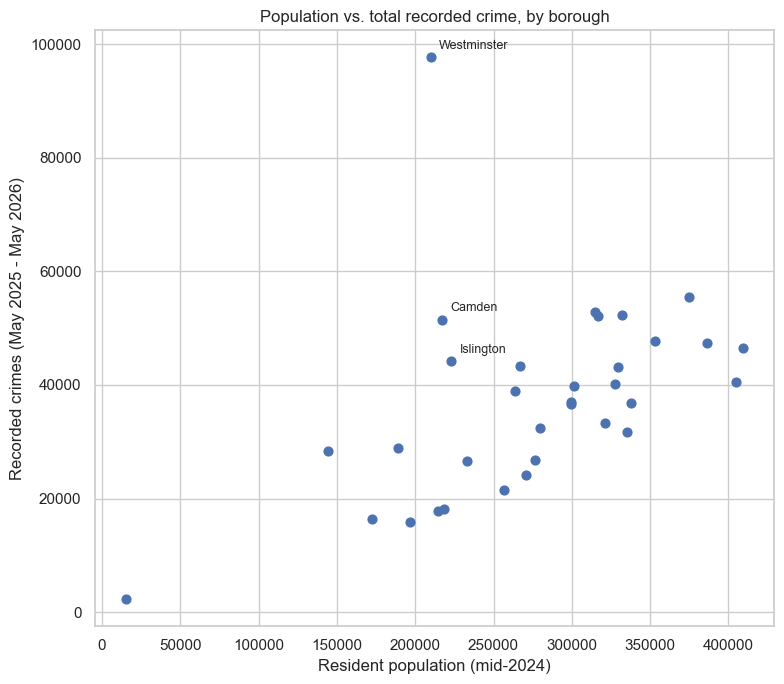

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(merged["Population"], merged["Crimes"], color="#4C72B0", s=40)

outliers = merged.sort_values("rate_per_1000", ascending=False).head(3)
for _, row in outliers.iterrows():
    ax.annotate(
        row["Borough"],
        (row["Population"], row["Crimes"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

ax.set_xlabel("Resident population (mid-2024)")
ax.set_ylabel("Recorded crimes (May 2025 - May 2026)")
ax.set_title("Population vs. total recorded crime, by borough")
fig.tight_layout()

## Next step

Population alone doesn't explain the remaining spread among the other 31
boroughs — the next natural question is whether **deprivation** (via the
Index of Multiple Deprivation) explains more of it than population does.